## 1. 卷积操作的数学定义

设输入特征图为 $X$，卷积核（滤波器）为 $K$（尺寸 $k_h \times k_w$）。深度学习框架里名为“卷积”的运算，数学上其实是**互相关（cross‑correlation）**：

$$(X \star K)(i, j) = \sum_{m=0}^{k_h-1}\sum_{n=0}^{k_w-1} X(i+m,\; j+n)\, K(m, n)$$

即核在输入上滑动，每个位置做**逐元素相乘再求和**，得到一个标量响应。配合步幅 $s$ 与填充 $p$，输出尺寸为：

$$H_{out} = \left\lfloor \frac{H_{in} + 2p - k}{s} \right\rfloor + 1 \qquad W_{out} = \left\lfloor \frac{W_{in} + 2p - k}{s} \right\rfloor + 1$$

**为什么能提取特征？** 每个核是一组可学习权重，等价于一个**模板/方向/边缘探测器**：当局部图像模式与核匹配时响应大，否则响应小。浅层核学到边缘、色块等低级特征，深层核组合出纹理、部件等高级特征——这就是“卷积 = 局部连接 + 权值共享 + 层次化特征提取”。

下面的 code cell 会：① 用纯 Python 实现上面的互相关公式并做边缘检测；② 用 `nn.Conv2d` 验证输出尺寸公式。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)

# ---- (a) 按数学定义手写 2D 互相关 ----
def corr2d(X, K):
    """严格按公式 (X ⋆ K)(i,j) = ΣΣ X(i+m,j+n)K(m,n) 实现。"""
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i + h, j:j + w] * K).sum()
    return Y

# 构造一张 6x8 的图：中间 4 列为 0，两侧为 1 -> 有两条竖直边界
X = torch.ones(6, 8)
X[:, 2:6] = 0.0
K = torch.tensor([[1.0, -1.0]])          # 水平方向差分核，检测竖直边缘
Y = corr2d(X, K)
print("输入 X:\n", X)
print("竖直边缘检测核 K =", K.tolist())
print("互相关输出 Y（非零处即检测到的竖直边界）:\n", Y)

# ---- (b) 用 nn.Conv2d 验证输出尺寸公式 ----
def conv_out_size(in_size, kernel, padding=0, stride=1):
    return (in_size + 2 * padding - kernel) // stride + 1

x = torch.randn(1, 3, 32, 32)            # batch=1, 3 通道, 32x32
conv = nn.Conv2d(in_channels=3, out_channels=16,
                 kernel_size=3, padding=1, stride=1)
out = conv(x)
print("\n[nn.Conv2d] 输入:", tuple(x.shape), "-> 输出:", tuple(out.shape))
print("[公式验证] H_out =", conv_out_size(32, kernel=3, padding=1, stride=1),
      "(应等于", out.shape[2], ")")
print("参数量 = k*k*C_in*C_out + bias =", 3 * 3 * 3 * 16 + 16,
      "| 实际 =", sum(p.numel() for p in conv.parameters()))

输入 X:
 tensor([[1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.]])
竖直边缘检测核 K = [[1.0, -1.0]]
互相关输出 Y（非零处即检测到的竖直边界）:
 tensor([[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.]])

[nn.Conv2d] 输入: (1, 3, 32, 32) -> 输出: (1, 16, 32, 32)
[公式验证] H_out = 32 (应等于 32 )
参数量 = k*k*C_in*C_out + bias = 448 | 实际 = 448


## 2. 残差连接如何解决梯度消失

普通“plain”网络把层堆成 $x_{l+1} = F(x_l)$。当网络很深时，反向传播的链式法则会把许多小于 1 的因子连乘，梯度指数级衰减 → **梯度消失**，浅层几乎学不动。

ResNet 改为学习**残差** $F(x) = H(x) - x$，即让层拟合“相对输入的增量”，并加一条恒等捷径：

$$x_{l+1} = x_l + F(x_l)$$

把浅层 $x_l$ 到深层 $x_L$ 的关系展开：

$$x_L = x_l + \sum_{i=l}^{L-1} F(x_i) \;\;\Rightarrow\;\; \frac{\partial x_L}{\partial x_l} = 1 + \frac{\partial}{\partial x_l}\sum_{i=l}^{L-1} F(x_i)$$

于是损失对浅层的梯度为：

$$\frac{\partial \mathcal{L}}{\partial x_l} = \frac{\partial \mathcal{L}}{\partial x_L}\,\frac{\partial x_L}{\partial x_l} = \frac{\partial \mathcal{L}}{\partial x_L}\left(1 + \frac{\partial}{\partial x_l}\sum_{i=l}^{L-1} F(x_i)\right)$$

**关键在于那个 “+1”**：它提供了一条梯度可以**无损直通**回浅层的高速公路，即使 $F$ 的导数很小，梯度也不会被连乘到 0。因此残差连接从结构上缓解了梯度消失，使上百甚至上千层的网络仍可训练。

下面的 code cell 用 30 层 `tanh` 网络做对照实验：相同初始化下，比较 plain 与 res 两种结构在反向传播后**对输入的梯度范数**与**首层权重梯度范数**。

In [2]:
import torch
import torch.nn as nn

torch.manual_seed(0)
D, N = 64, 30          # 隐层维度 64，堆叠 30 层（足够深以暴露梯度消失）

class PlainDeep(nn.Module):
    """x_{l+1} = act(W_l x_l)  —— 无捷径，梯度易消失。"""
    def __init__(self, d, n):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(d, d) for _ in range(n)])
        self.act = nn.Tanh()
    def forward(self, x):
        for l in self.layers:
            x = self.act(l(x))
        return x

class ResDeep(nn.Module):
    """x_{l+1} = x_l + act(W_l x_l)  —— 残差连接。"""
    def __init__(self, d, n):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(d, d) for _ in range(n)])
        self.act = nn.Tanh()
    def forward(self, x):
        for l in self.layers:
            x = x + self.act(l(x))     # 恒等捷径
        return x

plain, res = PlainDeep(D, N), ResDeep(D, N)
# 用较小的初始化，放大 plain 的消失效应（残差结构应仍能保持梯度）
for m in (plain, res):
    for l in m.layers:
        nn.init.normal_(l.weight, std=0.05)
        nn.init.zeros_(l.bias)

def grad_stats(model, x):
    x = x.detach().clone().requires_grad_(True)
    model.zero_grad()
    loss = model(x).sum()
    loss.backward()
    return x.grad.norm().item(), model.layers[0].weight.grad.norm().item()

x0 = torch.randn(8, D)
gi_p, gw_p = grad_stats(plain, x0)
gi_r, gw_r = grad_stats(res,   x0)

print(f"{'结构':<8}{'对输入的梯度范数':>20}{'首层 weight 梯度范数':>24}")
print(f"{'plain':<8}{gi_p:>20.4e}{gw_p:>24.4e}")
print(f"{'res':<8}{gi_r:>20.4e}{gw_r:>24.4e}")
print("\n结论：plain 的梯度被 30 层 tanh 连乘后趋近 0（消失）；"
      "res 因 '+1' 捷径，梯度数量级显著更大 -> 浅层仍能得到有效更新。")

结构                  对输入的梯度范数          首层 weight 梯度范数
plain             1.3465e-11              2.5637e-10
res               7.7071e+01              5.3361e+02

结论：plain 的梯度被 30 层 tanh 连乘后趋近 0（消失）；res 因 '+1' 捷径，梯度数量级显著更大 -> 浅层仍能得到有效更新。


## 3. ImageNet 预训练模型的迁移学习

**迁移学习**：把在大数据集（ImageNet，1000 类、上百万张图）上学到的通用视觉特征，迁移到我们的下游小数据集上，避免从零训练。两种主流策略：

- **特征提取（feature extraction）**：冻结整个 backbone，只训练新加的分类头。数据很少时用，快且不易过拟合。
- **微调（fine‑tuning）**：先冻结 backbone 训好分类头，再解冻（部分/全部）backbone 用小学习率一起精修。数据较多时用，精度更高。

本 cell 演示**特征提取**范式，三步走：
1. 加载带 ImageNet 权重的 ResNet‑18；
2. `requires_grad=False` 冻结全部参数；
3. 替换最后的 `fc` 全连接层为 `num_classes` 输出（新层默认可训练）。

最后用一个随机 batch 跑一次 forward+backward+step，验证“只有分类头在更新、流程通畅”。

In [4]:
import torch
import torch.nn as nn
from torchvision.models import resnet18

# ---- 1) 加载 ImageNet 预训练 ResNet-18（兼容新旧 API）----
try:
    from torchvision.models import ResNet18_Weights
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
except Exception:
    model = resnet18(pretrained=True)     # 旧版 torchvision 回退

# ---- 2) 冻结整个 backbone ----
for p in model.parameters():
    p.requires_grad = False

# ---- 3) 替换分类头（新层 requires_grad 默认 True）----
NUM_CLASSES = 10                          # 例如 CIFAR-10；改成你的类别数即可
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"可训练参数: {trainable:,} / 总参数: {total:,}  "
      f"({100 * trainable / total:.2f}%)  <- 应只占很小比例（仅 fc 头）")

# ---- sanity check：一次前向+反向+更新，确认仅分类头被优化 ----
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
criterion = nn.CrossEntropyLoss()

model.train()
xb = torch.randn(2, 3, 224, 224)          # 2 张假图
yb = torch.randint(0, NUM_CLASSES, (2,))
optimizer.zero_grad()
loss = criterion(model(xb), yb)
loss.backward()
optimizer.step()
print(f"sanity-check 一步完成，loss = {loss.item():.4f}（流程通畅即可）")

# 提示：要切换到真实数据，把 xb/yb 换成 DataLoader 的 batch 即可，例如：
#   from torchvision import datasets, transforms
#   tfm = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
#             transforms.ToTensor(),
#             transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
#   train_set = datasets.CIFAR10('./data', train=True,  download=True, transform=tfm)
#   train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/niumingcen/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


可训练参数: 5,130 / 总参数: 11,181,642  (0.05%)  <- 应只占很小比例（仅 fc 头）
sanity-check 一步完成，loss = 2.2074（流程通畅即可）


示例图来源: real (dog.jpg)


/var/folders/3p/qyn7yrs10k96y1mc_5k0_jpm0000gn/T/ipykernel_73823/3907778559.py:55: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3p/qyn7yrs10k96y1mc_5k0_jpm0000gn/T/ipykernel_73823/3907778559.py:55: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3p/qyn7yrs10k96y1mc_5k0_jpm0000gn/T/ipykernel_73823/3907778559.py:55: UserWarning: Glyph 21367 (\N{CJK UNIFIED IDEOGRAPH-5377}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3p/qyn7yrs10k96y1mc_5k0_jpm0000gn/T/ipykernel_73823/3907778559.py:55: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3p/qyn7yrs10k96y1mc_5k0_jpm0000gn/T/ipykernel_73823/3907778559.py:55: UserWarning: Glyph 26680 (\N{CJK UNIFIED IDEOGRAPH-6838}) missing from font(s) DejaVu

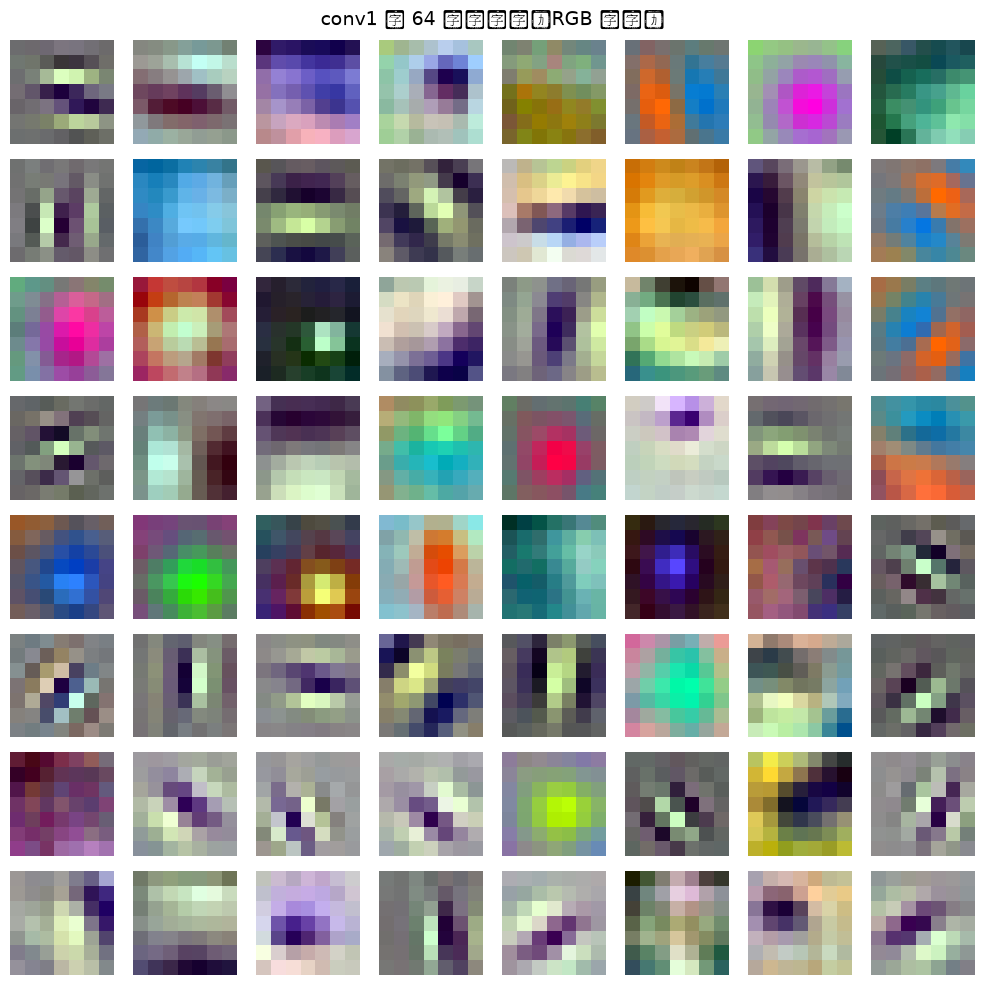

layer2 特征图形状 (C,H,W) = (128, 28, 28)


/var/folders/3p/qyn7yrs10k96y1mc_5k0_jpm0000gn/T/ipykernel_73823/3907778559.py:78: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3p/qyn7yrs10k96y1mc_5k0_jpm0000gn/T/ipykernel_73823/3907778559.py:78: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3p/qyn7yrs10k96y1mc_5k0_jpm0000gn/T/ipykernel_73823/3907778559.py:78: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3p/qyn7yrs10k96y1mc_5k0_jpm0000gn/T/ipykernel_73823/3907778559.py:78: UserWarning: Glyph 36947 (\N{CJK UNIFIED IDEOGRAPH-9053}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/3p/qyn7yrs10k96y1mc_5k0_jpm0000gn/T/ipykernel_73823/3907778559.py:78: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu

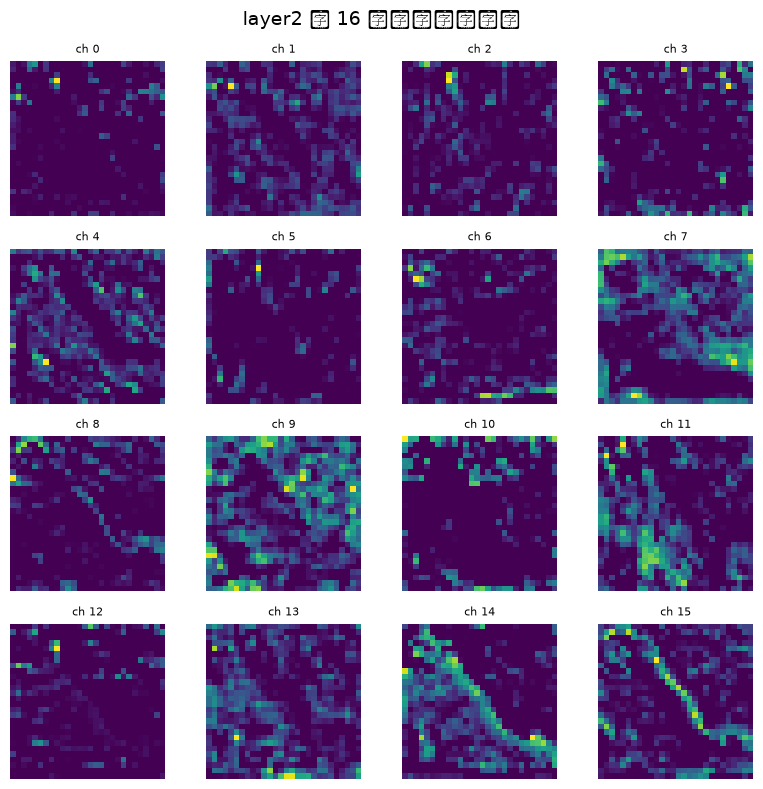

/var/folders/3p/qyn7yrs10k96y1mc_5k0_jpm0000gn/T/ipykernel_73823/3907778559.py:82: UserWarning: Glyph 36755 (\N{CJK UNIFIED IDEOGRAPH-8F93}) missing from font(s) DejaVu Sans.
  plt.title("输入图（反归一化）"); plt.tight_layout(); plt.show()
/var/folders/3p/qyn7yrs10k96y1mc_5k0_jpm0000gn/T/ipykernel_73823/3907778559.py:82: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.title("输入图（反归一化）"); plt.tight_layout(); plt.show()
/var/folders/3p/qyn7yrs10k96y1mc_5k0_jpm0000gn/T/ipykernel_73823/3907778559.py:82: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.title("输入图（反归一化）"); plt.tight_layout(); plt.show()
/var/folders/3p/qyn7yrs10k96y1mc_5k0_jpm0000gn/T/ipykernel_73823/3907778559.py:82: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.title("输入图（反归一化）"); plt.tight_layout(); plt.show()
/var/folders/3p/qyn7yrs10k96y1mc_5k0_jpm0000gn/T/ipykernel_73823/3907778

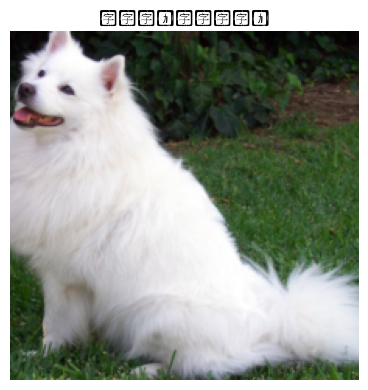

In [5]:
import io, urllib.request
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

%matplotlib inline

# ---- 准备一张示例图：优先联网下载，失败则合成（保证离线可跑）----
def load_example_image():
    try:
        url = "https://github.com/pytorch/hub/raw/master/images/dog.jpg"
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=8) as r:
            img = Image.open(io.BytesIO(r.read())).convert("RGB")
        return img, "real (dog.jpg)"
    except Exception as e:
        H = W = 224
        arr = np.zeros((H, W, 3), dtype=np.uint8)
        yy, xx = np.mgrid[0:H, 0:W]
        arr[..., 0] = (xx * 255 // W).astype(np.uint8)     # 水平红渐变
        arr[..., 1] = (yy * 255 // H).astype(np.uint8)     # 垂直绿渐变
        arr[60:160, 60:160, 2] = 220                        # 蓝色块
        arr[80:140, 80:140, 0] = 255                        # 中心红块
        return Image.fromarray(arr), f"synthetic (下载失败: {type(e).__name__})"

img_pil, src = load_example_image()
print("示例图来源:", src)

# ImageNet 标准预处理（独立于 weights 对象，兼容性好）
preprocess = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
img_tensor = preprocess(img_pil)                            # (3,224,224)

# 反归一化，用于把张量画回人眼可看的图
_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img_disp = (img_tensor.cpu() * _std + _mean).clamp(0, 1).permute(1, 2, 0).numpy()

model.eval()

# ---- (1) 可视化第一层卷积核 ----
k = model.conv1.weight.detach().cpu().clone()               # (64,3,7,7)
for i in range(k.shape[0]):                                 # 逐核 min-max 归一便于显示
    ki = k[i]; k[i] = (ki - ki.min()) / (ki.max() - ki.min() + 1e-8)
n = 64; cols = 8; rows = n // cols
fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(k[i].permute(1, 2, 0).numpy())                # (7,7,3) RGB 模板
    ax.axis("off")
fig.suptitle("conv1 的 64 个卷积核（RGB 模板）", fontsize=14)
plt.tight_layout(); plt.show()

# ---- (2) 用 hook 抓取中间层特征图并可视化 ----
activations = {}
def make_fwd_hook(name):
    def hook(m, inp, out):
        activations[name] = out.detach()
    return hook
model.layer2.register_forward_hook(make_fwd_hook("layer2"))

with torch.no_grad():
    _ = model(img_tensor.unsqueeze(0))
feat = activations["layer2"][0]                             # (C,H,W)
print("layer2 特征图形状 (C,H,W) =", tuple(feat.shape))

C = feat.shape[0]; show = min(16, C); cols = 4; rows = show // cols
fig, axes = plt.subplots(rows, cols, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    fmap = feat[i].cpu().numpy()
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    ax.imshow(fmap, cmap="viridis"); ax.axis("off")
    ax.set_title(f"ch {i}", fontsize=8)
fig.suptitle(f"layer2 前 {show} 个通道的特征图", fontsize=14)
plt.tight_layout(); plt.show()

# 顺手把原图也画出来，方便和下面的 Grad-CAM 对照
plt.figure(figsize=(4, 4)); plt.imshow(img_disp); plt.axis("off")
plt.title("输入图（反归一化）"); plt.tight_layout(); plt.show()

In [6]:
# ---- (3) Grad-CAM：网络做决策时关注的区域 ----
cam = {}
def make_cam_hook():
    def hook(m, inp, out):
        cam["feat"] = out.detach()                          # 前向激活
        out.register_hook(lambda g: cam.__setitem__("grad", g.detach()))  # 反向梯度
    return hook
model.layer2.register_forward_hook(make_cam_hook())

out = model(img_tensor.unsqueeze(0))
pred = int(out.argmax(1).item())
score = out[0, pred]                                        # 取预测类的 logit
model.zero_grad()
score.backward()                                            # 触发上面注册的梯度 hook

# 通道权重 = 梯度的全局平均池化；加权求和 + ReLU
w = cam["grad"].mean(dim=(2, 3), keepdim=True)              # (1,C,1,1)
cam_map = (w * cam["feat"]).sum(dim=1, keepdim=True).relu() # (1,1,H,W)
cam_map = cam_map - cam_map.min()
cam_map = cam_map / (cam_map.max() + 1e-8)
# 上采样到 224x224
cam_up = F.interpolate(cam_map, size=(224, 224),
                       mode="bilinear", align_corners=False)[0, 0].cpu().numpy()

try:
    from torchvision.models import ResNet18_Weights
    cats = ResNet18_Weights.DEFAULT.meta["categories"]
    pred_name = cats[pred]
except Exception:
    pred_name = f"class#{pred}"
print(f"Grad-CAM 针对预测类 = {pred_name} (idx={pred})")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(img_disp); axes[0].set_title("原图"); axes[0].axis("off")
axes[1].imshow(cam_up, cmap="jet"); axes[1].set_title("Grad-CAM 热力图"); axes[1].axis("off")
axes[2].imshow(img_disp)
axes[2].imshow(cam_up, cmap="jet", alpha=0.45)              # 叠加
axes[2].set_title(f"叠加（关注区域）\npred={pred_name}"); axes[2].axis("off")
plt.suptitle("Grad-CAM 类激活可视化", fontsize=14)
plt.tight_layout(); plt.show()

RuntimeError: cannot register a hook on a tensor that doesn't require gradient